In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Added pandas
import kagglehub # Added kagglehub import
from sklearn.model_selection import train_test_split, GridSearchCV # Added GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

Using Colab cache for faster access to the 'dogs-vs-cats' dataset.
Loading images from: /kaggle/input/dogs-vs-cats/train/train
Loaded 2000 images successfully
DataFrame shape: (2000, 769)
Training model...
Model training complete.
Accuracy: 0.6125
              precision    recall  f1-score   support

        cats       0.59      0.65      0.62       195
        dogs       0.63      0.58      0.60       205

    accuracy                           0.61       400
   macro avg       0.61      0.61      0.61       400
weighted avg       0.61      0.61      0.61       400


Testing with image: /kaggle/input/dogs-vs-cats/train/train/dog.3443.jpg


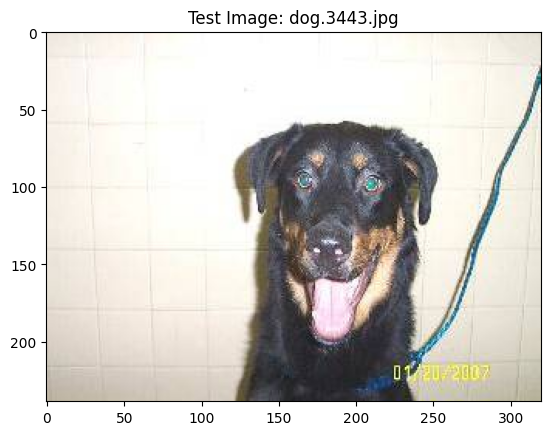

cats = 42.83%
dogs = 57.17%
The predicted image is : dogs


In [5]:
Categories = ['cats', 'dogs']

flat_data_arr = []   # input features
target_arr = []      # output labels

# Dataset path
datadir = kagglehub.dataset_download("biaiscience/dogs-vs-cats")

# Loading images
train_images_folder = os.path.join(datadir, 'train', 'train') # Corrected path to the actual image directory
print(f"Loading images from: {train_images_folder}")

if not os.path.exists(train_images_folder):
    print(f"Error: Training images folder not found at {train_images_folder}")
else:
    # Iterate through all files in the 'train' folder
    for img_name in os.listdir(train_images_folder):
        # Limit the number of images to load for faster execution
        if len(flat_data_arr) >= 2000: # Limiting to 2000 images (1000 cats, 1000 dogs)
            break

        if img_name.endswith(('.jpg', '.jpeg', '.png')): # Filter for image files
            img_path = os.path.join(train_images_folder, img_name)

            # Read the image using OpenCV
            img_array = cv2.imread(img_path)

            if img_array is not None:
                # Resize image using OpenCV
                img_resized = cv2.resize(img_array, (16, 16)) # cv2.resize expects (width, height)

                # Flatten image
                flat_data_arr.append(img_resized.flatten())

                # Determine label from filename
                if 'cat' in img_name.lower():
                    target_arr.append(Categories.index('cats'))
                elif 'dog' in img_name.lower():
                    target_arr.append(Categories.index('dogs'))
                else:
                    # Skip files that are not clearly cat or dog images
                    pass # print(f"Skipping unknown image file: {img_name}")
            else:
                print(f"Warning: Could not read image file: {img_path}")

    print(f'Loaded {len(flat_data_arr)} images successfully')


# Convert to numpy arrays
flat_data = np.array(flat_data_arr)
target = np.array(target_arr)

# Create dataframe
df = pd.DataFrame(flat_data)

# Add target column
df['Target'] = target

print(f"DataFrame shape: {df.shape}")

# INPUT DATA (all columns except Target)
x = df.iloc[:, :-1]

# OUTPUT DATA (Target column)
y = df.iloc[:, -1]

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=77,
    stratify=y
)

# Parameters for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.0001, 0.001, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

# Support Vector Classifier
svc = SVC(probability=True)

# GridSearchCV model
model = GridSearchCV(svc, param_grid)

# Train model
print("Training model...")
model.fit(x_train, y_train)
print("Model training complete.")

# Prediction
y_pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification Report
print(classification_report(y_test, y_pred, target_names=['cats', 'dogs']))

# Test Single Image
# Let's pick one image to test the model
# Find the first dog image in the training directory for demonstration
test_image_dir = os.path.join(datadir, 'train', 'train') # Also correct for testing
test_image_path = None

if os.path.exists(test_image_dir):
    for fname in os.listdir(test_image_dir):
        if fname.startswith('dog') and fname.endswith(('.jpg', '.jpeg', '.png')):
            test_image_path = os.path.join(test_image_dir, fname)
            break

if test_image_path:
    print(f"\nTesting with image: {test_image_path}")
    img_to_predict = cv2.imread(test_image_path)

    if img_to_predict is not None:
        plt.imshow(cv2.cvtColor(img_to_predict, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
        plt.title(f"Test Image: {os.path.basename(test_image_path)}")
        plt.show()

        # Resize image for prediction
        img_resize_for_pred = cv2.resize(img_to_predict, (16, 16))

        # Flatten image
        flattened_img = [img_resize_for_pred.flatten()]

        # Predict probability
        probability = model.predict_proba(flattened_img)

        for ind, val in enumerate(Categories):
            print(f'{val} = {probability[0][ind] * 100:.2f}%')

        # Final prediction
        print("The predicted image is : " + Categories[model.predict(flattened_img)[0]])
    else:
        print(f"Failed to load the selected test image: {test_image_path}")
else:
    print(f"Could not find a sample dog image for testing in {test_image_dir}.")